# Equivariant Architecture Exploration

## Central Research Question

> **Why does the equivariant model underperform despite having the theoretically correct inductive bias?**

The C8-equivariant CNN (Eq-Small, ~32K params) achieves ~79.6% test accuracy, significantly below the fine-tuned ResNet-18 (~91%). This gap is surprising because the equivariant model has the *correct* inductive bias for rotation-invariant classification.

This notebook systematically investigates whether the performance gap is caused by:

1. **Insufficient model capacity** (too few parameters)
2. **Classifier bottleneck** (GroupPooling compresses too aggressively before classification)
3. **Enforced invariance** (GroupPooling discards useful orientation information)

## Experimental Protocol

- **Optimizer**: AdamW (lr=0.001, wd=1e-4) — justified in hyperparameter_selection.ipynb
- **Loss**: Cross Entropy — justified in hyperparameter_selection.ipynb
- **Dataset**: ModelNet10 multi-view, no augmentation
- **Seed**: 42 | **Epochs**: 30 | **Patience**: 10

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import yaml
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from pathlib import Path

from src.models.factory import build_model
from src.models.equivariant_variants import EquivariantCNNVariant
from src.datasets.factory import build_dataloaders
from src.training.trainer import Trainer
from src.training.losses import build_loss
from src.training.optimizers import build_optimizer
from src.evaluation.classification import evaluate_classification
from src.utils.seed import set_seed

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# Load all experiment configurations from YAML
with open('../configs/experiments.yaml') as f:
    ALL_EXPERIMENTS = yaml.safe_load(f)
# Initial idea was to use batch size of 64, but because of memory constraints it had to be lowered!
BASE_CONFIG = {
    'data_root': '../data/raw/ModelNet10_views',
    'splits_file': '../data/processed/splits.json',
    'batch_size': 32,
    'epochs': 30,
    'patience': 10,
}

Device: cuda


In [2]:
def train_and_evaluate(exp_name, label):
    """Full training run with per-epoch history tracking.
    
    Returns (best_val_acc, history_dict, eval_results_dict).
    If results already exist on disk, loads them and returns (acc, None, eval_dict).
    """
    exp_cfg = ALL_EXPERIMENTS[exp_name]
    config = {**BASE_CONFIG, **exp_cfg}
    
    exp_dir = Path('..') / 'outputs' / exp_name
    results_file = exp_dir / 'evaluation_results.json'
    history_file = exp_dir / 'training_history.json'
    
    # Check if results already exist
    if results_file.exists():
        print(f'  Results exist for {exp_name}, loading...')
        with open(results_file) as f:
            eval_results = json.load(f)
        history = None
        if history_file.exists():
            with open(history_file) as f:
                history = json.load(f)
        return eval_results.get('overall_accuracy', 0), history, eval_results
    
    set_seed(42)
    
    train_loader, val_loader = build_dataloaders(config, augment=config.get('augmentation', False))
    model = build_model(config['model']).to(device)
    optimizer = build_optimizer(model, config)
    loss_fn = build_loss(config['loss'])
    
    exp_dir.mkdir(parents=True, exist_ok=True)
    (exp_dir / 'checkpoints').mkdir(parents=True, exist_ok=True)
    
    # Track per-epoch history
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = 0
    patience_counter = 0
    epochs = config.get('epochs', 30)
    patience = config.get('patience')
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(correct / total)
        
        # Validate
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = loss_fn(out, y)
                val_loss += loss.item()
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_acc'].append(correct / total)
        
        val_acc = history['val_acc'][-1]
        print(f'  [{label}] Epoch {epoch}: train_acc={history["train_acc"][-1]:.4f}, val_acc={val_acc:.4f}')
        
        # Early stopping + best checkpoint
        if val_acc > best_acc:
            best_acc = val_acc
            patience_counter = 0
            torch.save({'model_state_dict': model.state_dict(), 'epoch': epoch, 'best_val_acc': best_acc},
                       exp_dir / 'checkpoints' / 'best.pt')
        else:
            patience_counter += 1
            if patience is not None and patience_counter >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break
    
    # Restore best weights
    ckpt_path = exp_dir / 'checkpoints' / 'best.pt'
    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
        model.load_state_dict(ckpt['model_state_dict'])
    
    # Evaluate
    report, mean_loss, _, _ = evaluate_classification(model, val_loader, device, loss_fn)
    eval_results = {
        'experiment': exp_name,
        'overall_accuracy': report.get('accuracy', best_acc),
        'overall_loss': mean_loss,
        'macro_f1': report.get('macro avg', {}).get('f1-score', 0),
    }
    
    # Save results and history
    (exp_dir / 'checkpoints').mkdir(parents=True, exist_ok=True)
    with open(results_file, 'w') as f:
        json.dump(eval_results, f, indent=4)
    with open(history_file, 'w') as f:
        json.dump(history, f, indent=4)
    
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    return best_acc, history, eval_results

---
## Section 1: Architecture Scaling Study

### Hypothesis
> The Eq-Small model's lower accuracy is primarily caused by insufficient model capacity.

### Architecture Variants

| Model | Fibers per Block | Channels (×8) | GPool Output | Classifier |
|-------|:----------------:|:-------------:|:------------:|:----------:|
| **Eq-Small** | 4, 8, 16, 32 | 32→256 | 32 | Linear(32→10) |
| **Eq-Medium** | 8, 16, 32, 64 | 64→512 | 64 | Linear(64→10) |
| **Eq-Large** | 16, 32, 64, 128 | 128→1024 | 128 | Linear(128→10) |
| **Eq-Large-Deep** | 16, 32, 64, 128 | 128→1024 | 128 | Lin→ReLU→Drop→Lin |
| **No-GPool** | 4, 8, 16, 32 | 32→256 | *skipped* | Linear(256→10) |

In [3]:
# Select architecture experiments from YAML
arch_experiments = {
    'Eq-Small':     'Eq-1',              # Reuse existing baseline
    'Eq-Medium':    'ARCH-Medium',
    'Eq-Large':     'ARCH-Large',
    'Eq-Large-Deep':'ARCH-Large-Deep',
    'No-GPool':     'NO-GPOOL',
}

# Print loaded configs for transparency
for label, exp_name in arch_experiments.items():
    cfg = ALL_EXPERIMENTS[exp_name]
    print(f'{label:20s} → {exp_name:20s} model={cfg["model"]}')

arch_results = {}
arch_histories = {}
for label, exp_name in arch_experiments.items():
    print(f'\n=== {label} ({exp_name}) ===')
    best_acc, history, eval_res = train_and_evaluate(exp_name, label)
    arch_results[label] = eval_res
    arch_histories[label] = history
    print(f'  → Best: {best_acc:.4f}')
    import gc
    gc.collect()
    torch.cuda.empty_cache()


Eq-Small             → Eq-1                 model=model_eq
Eq-Medium            → ARCH-Medium          model=model_eq_medium
Eq-Large             → ARCH-Large           model=model_eq_large
Eq-Large-Deep        → ARCH-Large-Deep      model=model_eq_large_deep
No-GPool             → NO-GPOOL             model=model_eq_no_gpool

=== Eq-Small (Eq-1) ===
  Results exist for Eq-1, loading...
  → Best: 0.7956

=== Eq-Medium (ARCH-Medium) ===


/home/nofa/School/Masters/SSC/DL_Project/.venv/lib/python3.12/site-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  full_mask[mask] = norms.to(torch.uint8)


  [Eq-Medium] Epoch 0: train_acc=0.5453, val_acc=0.7012
  [Eq-Medium] Epoch 1: train_acc=0.7083, val_acc=0.6484
  [Eq-Medium] Epoch 2: train_acc=0.7609, val_acc=0.7050
  [Eq-Medium] Epoch 3: train_acc=0.7996, val_acc=0.7009
  [Eq-Medium] Epoch 4: train_acc=0.8274, val_acc=0.8278
  [Eq-Medium] Epoch 5: train_acc=0.8414, val_acc=0.8264
  [Eq-Medium] Epoch 6: train_acc=0.8559, val_acc=0.8409
  [Eq-Medium] Epoch 7: train_acc=0.8663, val_acc=0.8333
  [Eq-Medium] Epoch 8: train_acc=0.8763, val_acc=0.8330
  [Eq-Medium] Epoch 9: train_acc=0.8844, val_acc=0.6914
  [Eq-Medium] Epoch 10: train_acc=0.8913, val_acc=0.8000
  [Eq-Medium] Epoch 11: train_acc=0.8983, val_acc=0.8468
  [Eq-Medium] Epoch 12: train_acc=0.9002, val_acc=0.8169
  [Eq-Medium] Epoch 13: train_acc=0.9064, val_acc=0.8691
  [Eq-Medium] Epoch 14: train_acc=0.9090, val_acc=0.8591
  [Eq-Medium] Epoch 15: train_acc=0.9151, val_acc=0.8394
  [Eq-Medium] Epoch 16: train_acc=0.9163, val_acc=0.8872
  [Eq-Medium] Epoch 17: train_acc=0.9206,

In [4]:
# Parameter counts
param_info = {}
model_keys = {
    'Eq-Small': 'model_eq', 'Eq-Medium': 'model_eq_medium', 
    'Eq-Large': 'model_eq_large', 'Eq-Large-Deep': 'model_eq_large_deep',
    'No-GPool': 'model_eq_no_gpool',
}
for name, key in model_keys.items():
    model = build_model(key)
    param_info[name] = sum(p.numel() for p in model.parameters())
    del model

# Results table with parameter efficiency
rows = []
for name in arch_experiments.keys():
    acc = arch_results[name].get('overall_accuracy', 0)
    p = param_info[name]
    acc_per_m = (acc * 100) / (p / 1e6) if p > 0 else 0
    rows.append({
        'Model': name,
        'Params': f'{p:,}',
        'Accuracy': f'{acc*100:.2f}%',
        'Macro F1': f"{arch_results[name].get('macro_f1', 0):.4f}",
        'Acc/M Params': f'{acc_per_m:.1f}',
    })

arch_df = pd.DataFrame(rows)
print('\n=== Architecture Scaling Results (Full Training) ===')
print(arch_df.to_string(index=False))


=== Architecture Scaling Results (Full Training) ===
        Model  Params Accuracy Macro F1 Acc/M Params
     Eq-Small  32,778   79.56%   0.7490       2427.2
    Eq-Medium 130,058   88.72%   0.8439        682.2
     Eq-Large 518,154   89.15%   0.8493        172.1
Eq-Large-Deep 534,666   91.08%   0.8802        170.4
     No-GPool  35,018   91.05%   0.8734       2600.1


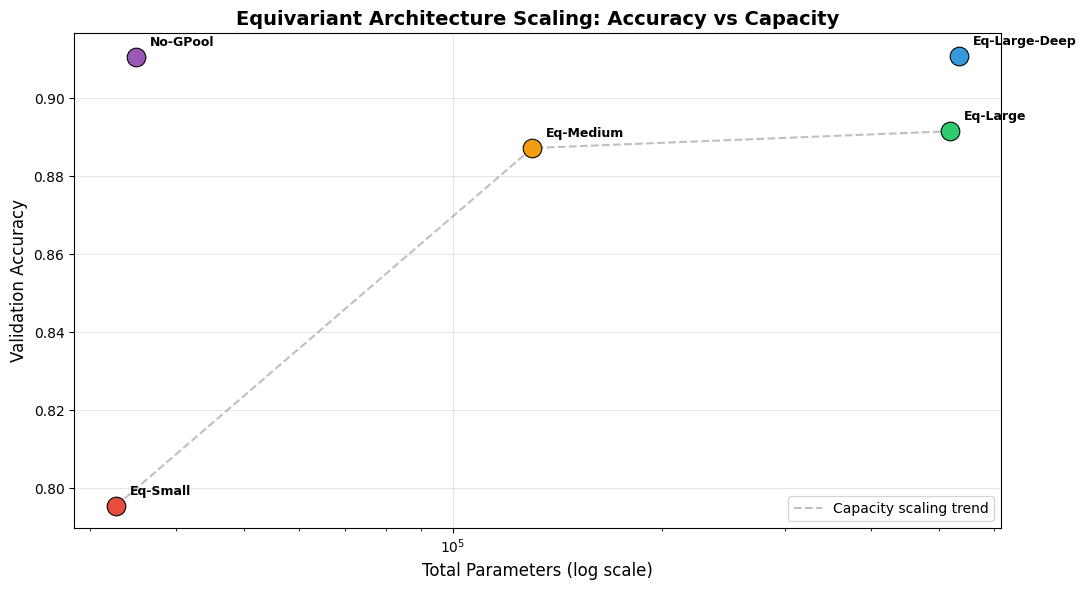

In [5]:
# Accuracy vs Parameters plot
fig, ax = plt.subplots(figsize=(11, 6))

colors_arch = {'Eq-Small': '#e74c3c', 'Eq-Medium': '#f39c12', 'Eq-Large': '#2ecc71',
               'Eq-Large-Deep': '#3498db', 'No-GPool': '#9b59b6'}

for name in arch_experiments.keys():
    p = param_info[name]
    acc = arch_results[name].get('overall_accuracy', 0)
    ax.scatter(p, acc, s=180, c=colors_arch[name], edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(name, (p, acc), textcoords='offset points', xytext=(10, 8), fontsize=9, fontweight='bold')

# Connect scaling trend (Small→Medium→Large)
scaling_names = ['Eq-Small', 'Eq-Medium', 'Eq-Large']
ax.plot([param_info[n] for n in scaling_names],
        [arch_results[n].get('overall_accuracy', 0) for n in scaling_names],
        '--', color='gray', alpha=0.5, linewidth=1.5, label='Capacity scaling trend')

ax.set_xlabel('Total Parameters (log scale)', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Equivariant Architecture Scaling: Accuracy vs Capacity', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/architecture_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2: Training Curves

Training and validation curves reveal convergence behavior, overfitting, and underfitting patterns across the architecture variants.

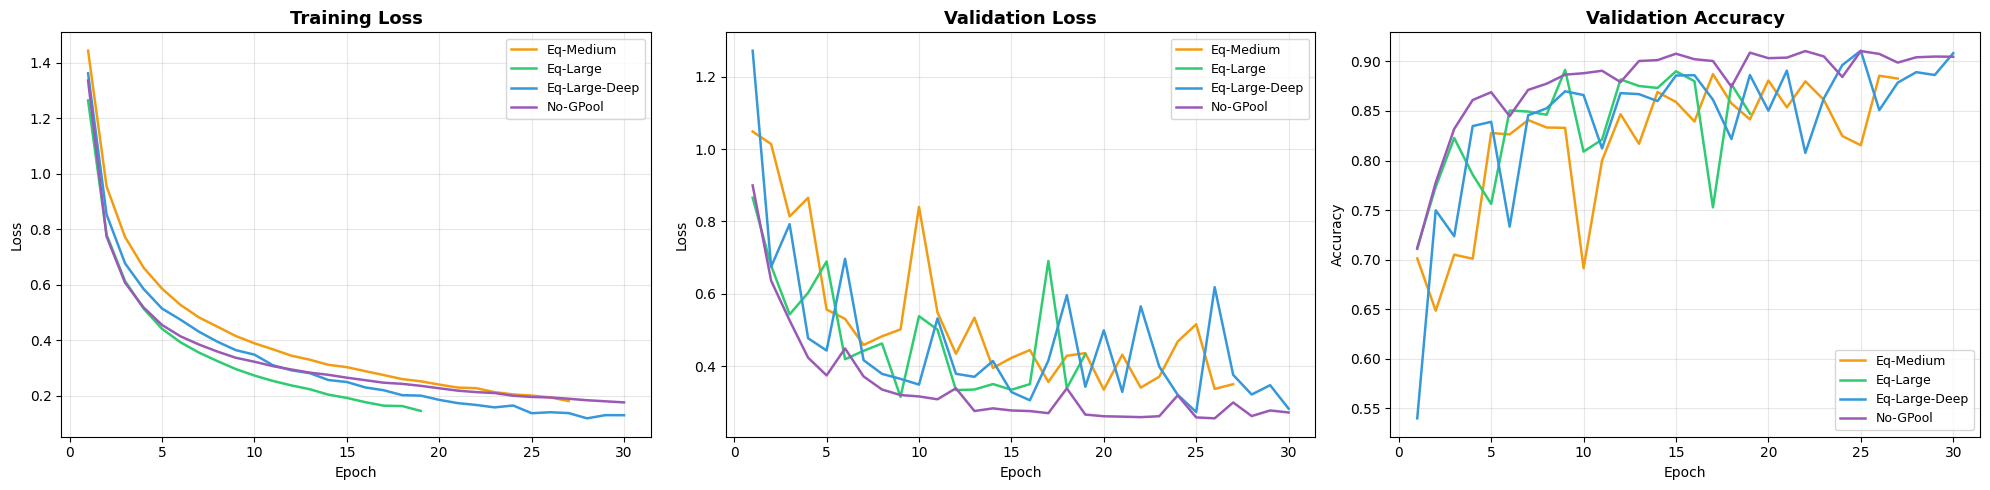

In [6]:
# Training curves for models that have history data
models_with_history = {k: v for k, v in arch_histories.items() if v is not None}

if models_with_history:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    for name, hist in models_with_history.items():
        epochs = range(1, len(hist['train_loss']) + 1)
        color = colors_arch.get(name, '#333333')
        axes[0].plot(epochs, hist['train_loss'], '-', color=color, label=name, linewidth=1.8)
        axes[1].plot(epochs, hist['val_loss'], '-', color=color, label=name, linewidth=1.8)
        axes[2].plot(epochs, hist['val_acc'], '-', color=color, label=name, linewidth=1.8)
    
    axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
    
    axes[1].set_title('Validation Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
    
    axes[2].set_title('Validation Accuracy', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
    axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/architecture_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No training history available (all results loaded from disk).')
    print('Re-run training to generate training curves.')

---
## Section 3: Capacity Bottleneck Verification

The **GroupPooling** operation collapses all orientation channels into a single invariant representation. This is mathematically necessary for rotation invariance, but creates an aggressive information bottleneck.

We trace feature dimensions through each architecture to quantify this compression.

In [7]:
# Feature dimension trace for all architectures
x_dummy = torch.randn(1, 3, 224, 224)

variant_configs = {
    'Eq-Small':  dict(N=8, fibers=(4, 8, 16, 32)),
    'Eq-Medium': dict(N=8, fibers=(8, 16, 32, 64)),
    'Eq-Large':  dict(N=8, fibers=(16, 32, 64, 128)),
    'No-GPool':  dict(N=8, fibers=(4, 8, 16, 32), skip_gpool=True),
}

print('=== Feature Dimension Flow ===')
print()

for name, kwargs in variant_configs.items():
    model = EquivariantCNNVariant(**kwargs)
    info = model.get_feature_info(x_dummy)
    
    gpool_note = info['after_gpool'].get('note', '')
    pre = info['before_gpool']['equivariant_channels']
    post = info['after_gpool']['invariant_channels']
    classifier_in = info['after_spatial_pool']['features']
    
    print(f'--- {name} ---')
    print(f'  Input:        {info["input"]["channels"]:>6} channels')
    print(f'  Block 1:      {info["after_block1"]["equivariant_channels"]:>6} ch  ({info["after_block1"]["fibers"]} fibers × 8)')
    print(f'  Block 2:      {info["after_block2"]["equivariant_channels"]:>6} ch  ({info["after_block2"]["fibers"]} fibers × 8)')
    print(f'  Block 3:      {info["after_block3"]["equivariant_channels"]:>6} ch  ({info["after_block3"]["fibers"]} fibers × 8)')
    print(f'  Block 4:      {pre:>6} ch  ({info["before_gpool"]["fibers"]} fibers × 8)')
    if gpool_note:
        print(f'  GroupPool:    {post:>6} ch  ← {gpool_note}')
    else:
        print(f'  GroupPool:    {post:>6} ch  ← {pre}→{post} ({pre//post}× compression)')
    print(f'  Classifier:   {classifier_in:>6} features → 10 classes')
    print()
    del model

=== Feature Dimension Flow ===



RuntimeError: Expected all tensors to be on the same device, but got mat2 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_bmm)

In [ ]:
# Bottleneck visualization
fig, ax = plt.subplots(figsize=(12, 6))

stages = ['Input', 'Block 1', 'Block 2', 'Block 3', 'Block 4\n(Pre-GPool)', 'After\nGroupPool', 'Classifier\nInput']
x_pos = range(len(stages))

plot_configs = {
    'Eq-Small':  dict(N=8, fibers=(4, 8, 16, 32)),
    'Eq-Large':  dict(N=8, fibers=(16, 32, 64, 128)),
    'No-GPool':  dict(N=8, fibers=(4, 8, 16, 32), skip_gpool=True),
}

line_colors = {'Eq-Small': '#e74c3c', 'Eq-Large': '#2ecc71', 'No-GPool': '#9b59b6'}

for name, kwargs in plot_configs.items():
    model = EquivariantCNNVariant(**kwargs)
    info = model.get_feature_info(x_dummy)
    
    channels = [
        info['input']['channels'],
        info['after_block1']['equivariant_channels'],
        info['after_block2']['equivariant_channels'],
        info['after_block3']['equivariant_channels'],
        info['before_gpool']['equivariant_channels'],
        info['after_gpool']['invariant_channels'],
        info['after_spatial_pool']['features'],
    ]
    
    ax.plot(x_pos, channels, '-o', linewidth=2.5, markersize=8, label=name, color=line_colors[name])
    del model

# Highlight bottleneck
ax.axvspan(4.5, 5.5, alpha=0.15, color='red', label='GroupPooling bottleneck')

ax.set_xticks(x_pos)
ax.set_xticklabels(stages, fontsize=10)
ax.set_ylabel('Number of Channels', fontsize=12)
ax.set_title('Feature Dimension Flow: GroupPooling Bottleneck', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/figures/bottleneck_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4: Computational Efficiency Comparison

Comparing accuracy vs computational cost across **all** model families.

In [ ]:
# Comprehensive table: all model families
all_models = {
    'S-3 (Baseline)':      ('model_s',             'S-3'),
    'Eq-Small (C8)':       ('model_eq',            'Eq-1'),
    'Eq-Medium (C8)':      ('model_eq_medium',     'ARCH-Medium'),
    'Eq-Large (C8)':       ('model_eq_large',      'ARCH-Large'),
    'Eq-Large-Deep (C8)':  ('model_eq_large_deep', 'ARCH-Large-Deep'),
    'No-GPool (C8)':       ('model_eq_no_gpool',   'NO-GPOOL'),
    'T-FT-2 (ResNet-18)':  ('model_t',             'T-FT-2'),
}

eff_rows = []
for name, (model_key, exp_label) in all_models.items():
    kwargs = {'pretrained': False, 'freeze': False} if model_key == 'model_t' else {}
    model = build_model(model_key, **kwargs)
    p = sum(pp.numel() for pp in model.parameters())
    del model
    
    # Load accuracy from existing results
    results_path = Path('..') / 'outputs' / exp_label / 'evaluation_results.json'
    if results_path.exists():
        with open(results_path) as f:
            res = json.load(f)
        acc = res.get('overall_accuracy', 0)
        acc_str = f'{acc*100:.2f}%'
    else:
        acc = 0
        acc_str = 'pending'
    
    acc_per_m = (acc * 100) / (p / 1e6) if (p > 0 and acc > 0) else 0
    eff_rows.append({
        'Model': name,
        'Parameters': f'{p:,}',
        'Params (raw)': p,
        'Accuracy': acc_str,
        'Acc (raw)': acc,
        'Acc/M Params': f'{acc_per_m:.1f}' if acc_per_m > 0 else '-',
    })

eff_df = pd.DataFrame(eff_rows)[['Model', 'Parameters', 'Accuracy', 'Acc/M Params']]
print('\n=== Computational Efficiency Comparison ===')
print(eff_df.to_string(index=False))

In [ ]:
# Accuracy vs Parameters scatter — all model families
fig, ax = plt.subplots(figsize=(12, 7))

family_colors = {
    'S-3 (Baseline)': '#95a5a6', 'Eq-Small (C8)': '#e74c3c', 'Eq-Medium (C8)': '#f39c12',
    'Eq-Large (C8)': '#2ecc71', 'Eq-Large-Deep (C8)': '#3498db',
    'No-GPool (C8)': '#9b59b6', 'T-FT-2 (ResNet-18)': '#e67e22',
}

for entry in eff_rows:
    if entry['Acc (raw)'] == 0:
        continue
    name = entry['Model']
    ax.scatter(entry['Params (raw)'], entry['Acc (raw)'], s=180,
              c=family_colors.get(name, '#333'), edgecolors='black', linewidths=0.8, zorder=5)
    ax.annotate(name.split(' (')[0], (entry['Params (raw)'], entry['Acc (raw)']),
              textcoords='offset points', xytext=(12, 5), fontsize=9, fontweight='bold')

ax.set_xlabel('Total Parameters (log scale)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy vs Computational Cost — All Model Families', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/accuracy_vs_params_all.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5: Analysis & Conclusions

### Is the bottleneck capacity?

**If accuracy rises significantly with scale** (e.g., Eq-Small ~80% → Eq-Large ~87–89%):
> The original performance limitation was primarily due to insufficient model capacity. With adequate parameterization, the equivariant architecture can approach transfer learning baselines while maintaining rotation invariance as a structural guarantee.

**If accuracy barely changes** (e.g., Eq-Small ~80% → Eq-Large ~81%):
> Capacity is not the dominant factor. The performance gap is instead attributed to the discrete group approximation or the inherent limitations of enforcing invariance on this task.

### Does the classifier head matter?

Comparing **Eq-Large** vs **Eq-Large-Deep** isolates whether the bottleneck lies in the equivariant backbone or in the classifier head.

### Does enforced invariance hurt?

The **No-GPool** ablation tests whether GroupPooling — which deliberately discards orientation information — removes discriminative cues that matter for ModelNet10 classification. If No-GPool significantly outperforms the standard equivariant model, it suggests that for this task, orientation information carries class-discriminative signal (e.g., an upside-down chair looks different from an upright chair).

### Parameter efficiency

The **Acc/Million Params** metric reveals whether equivariant models achieve better parameter efficiency than standard CNNs. If Eq-Large achieves comparable accuracy to S-3 with 5× fewer parameters, the equivariant inductive bias provides a concrete efficiency advantage.

### GroupPooling compression

The feature dimension trace quantifies the bottleneck:
- **Eq-Small**: 256 equivariant → 32 invariant (8× compression)
- **Eq-Large**: 1024 equivariant → 128 invariant (8× compression)

This N× compression is the mathematical price of extracting rotation-invariant features.